# Example 5: GNSS Measurement Simulation for a Lunar Satellite

This notebook simulates GPS signal reception by a lunar satellite in an Elliptical Lunar Frozen Orbit (ELFO).

**Workflow:**
1. Propagate the ELFO for one orbit period (~13.2 h) with multibody dynamics
2. Load the GPS constellation from SP3 precise-ephemeris files via C++ `GnssConstellation`
3. Run `GNSSMeasurements.precompute()` to compute visibility and link-budget (C/N0) at every epoch
4. Visualize number of visible satellites, C/N0 time history, and lunar-satellite directions on GPS TX antenna patterns

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import Counter
from datetime import datetime, timezone

import pylupnt as pnt
from pylupnt.interfaces.gnss_file_loader import SP3Loader as PySP3Loader

[00.00][PyLuPNT] Initializing


## 1. Simulation Epoch

In [2]:
t0_tdb = pnt.gregorian_to_time(2026, 1, 1, 0, 0, 0.0)
t0_tai = pnt.convert_time(t0_tdb, pnt.TDB, pnt.TAI)
print(f"Epoch (TDB): {pnt.time_to_gregorian_string(t0_tdb)} TDB")
print(f"t0_tdb={t0_tdb:.3f} s  t0_tai={t0_tai:.3f} s")

Epoch (TDB): 2026-01-01T00:00:00.000 TDB
t0_tdb=820497600.000 s  t0_tai=820497567.816 s


## 2. ELFO Definition

In [3]:
a    = 6541.4e3
e    = 0.6
i    = 56.2 * pnt.RAD
raan = 0.0 * pnt.RAD
w    = 90.0 * pnt.RAD
M0   = 0.0 * pnt.RAD

coe0_op = np.array([a, e, i, raan, w, M0])
period  = float(pnt.get_orbital_period(a, pnt.GM_MOON))
print(f"Orbital period: {period:.1f} s  ({period/pnt.SECS_HOUR:.2f} h)")

rv0_op  = pnt.classical_to_cart(coe0_op, pnt.GM_MOON)
rv0_mci = pnt.convert_frame(t0_tdb, rv0_op, pnt.MOON_OP, pnt.MOON_CI)
print(f"r0 (MCI): {rv0_mci[:3]/1e3} km")

Orbital period: 47474.9 s  (13.19 h)
r0 (MCI): [ 410.80116383  178.48187281 2577.93965377] km


## 3. Multibody Dynamics Setup

In [4]:
dyn = pnt.NBodyDynamics()
dyn.set_frame(pnt.MOON_CI)
dyn.set_units(pnt.SI_UNITS)
dyn.add_body(pnt.create_body(pnt.MOON, 2, 2))
dyn.add_body(pnt.create_body(pnt.EARTH))
dyn.add_body(pnt.create_body(pnt.SUN))
dyn.set_srp_coeff(1.8, 0.02, 10.0)
dyn.set_integrator(pnt.IntegratorType.RKF45)
params = pnt.IntegratorParams()
params.reltol = 1e-10
params.abstol = 1e-6
dyn.set_integrator_params(params)

## 4. Propagate ELFO for One Orbit Period

In [5]:
DT_RX     = 300.0
N_RX      = int(period / DT_RX) + 1
t_tdb_arr = t0_tdb + np.arange(N_RX) * DT_RX
t_tai_arr = pnt.convert_time(t_tdb_arr, pnt.TDB, pnt.TAI)
t_hrs     = (t_tai_arr - t_tai_arr[0]) / pnt.SECS_HOUR

rv_mci = np.array(dyn.propagate(rv0_mci, t_tdb_arr))
print(f"Propagated {N_RX} epochs ({DT_RX:.0f}-s steps) over {period/pnt.SECS_HOUR:.2f} h")

Propagated 159 epochs (300-s steps) over 13.19 h


In [6]:
# Convert MCI -> ECI for GNSS measurement model
rv_eci = np.array(pnt.convert_frame(t_tdb_arr, rv_mci, pnt.MOON_CI, pnt.ECI))

# 8-element state [r, v, clock_bias=0, clock_drift=0]
rx_states_eci = np.hstack([rv_eci, np.zeros((N_RX, 2))])

alt_km = (np.linalg.norm(rv_mci[:, :3], axis=1) - pnt.R_MOON) / 1e3
print(f"Apoapsis: {alt_km.max():.0f} km above Moon surface")
print(f"Periapsis: {alt_km.min():.0f} km above Moon surface")

Apoapsis: 8727 km above Moon surface
Periapsis: 879 km above Moon surface


## 5. Load GPS and Galileo Constellations from SP3 Files

The Python `SP3Loader` downloads and caches the COD MGEX final-product SP3 file. We query GPS (G) and Galileo (E) satellite ECI states on a 5-minute grid and pass them to the C++ `GnssConstellation`.

In [7]:
START_DT = datetime(2026, 1, 1, tzinfo=timezone.utc)
SIM_T_S  = period + 3600

print("Downloading/loading SP3 file...")
sp3_py = PySP3Loader(target_dt=START_DT, sim_t=int(SIM_T_S))
print(f"Loaded {len(sp3_py.sats)} satellites")

Downloading/loading SP3 file...
SP3 file for GPS TIME: 2025-12-31 00:00:17.999999 already exists at /home/kiiyama/LuPNT/output/gnss_files/sp3/COD0MGXFIN_20253650000_01D_05M_ORB.SP3. Skipping download.
SP3 file for GPS TIME: 2026-01-01 00:00:17.999999 already exists at /home/kiiyama/LuPNT/output/gnss_files/sp3/COD0MGXFIN_20260010000_01D_05M_ORB.SP3. Skipping download.
SP3 file for GPS TIME: 2026-01-02 00:00:17.999999 already exists at /home/kiiyama/LuPNT/output/gnss_files/sp3/COD0MGXFIN_20260020000_01D_05M_ORB.SP3. Skipping download.
Loaded 123 satellites


In [8]:
DT_SAT    = 300.0
# Start one step before t0_tai: light-time iteration queries the GPS satellite
# at t_tx = t_rx - range/c (~1.3 s for cislunar distances), so the Chebyshev
# fit must cover slightly before the first receiver epoch.
MARGIN_S  = DT_SAT
N_SAT     = int((SIM_T_S + MARGIN_S) / DT_SAT) + 1
t_sat_tai = (t0_tai - MARGIN_S) + np.arange(N_SAT) * DT_SAT

gps_prns_sp3 = sorted([int(s[1:]) for s in sp3_py.sats if s.startswith('G')])
print(f"GPS PRNs in SP3: {gps_prns_sp3}")

rv_eci_list = []
valid_prns  = []
for prn in gps_prns_sp3:
    try:
        rv_sat, _ = sp3_py.get_posvelclock('G', prn, t_sat_tai.tolist(), pnt.ECI)
        rv_eci_list.append(np.array(rv_sat, dtype=np.float64))
        valid_prns.append(prn)
    except Exception as ex:
        print(f"  G{prn:02d}: skipped ({ex})")

print(f"Queried {len(valid_prns)} GPS satellites")

GPS PRNs in SP3: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Queried 32 GPS satellites


In [9]:
gal_prns_sp3 = sorted([int(s[1:]) for s in sp3_py.sats if s.startswith('E')])
print(f'Galileo PRNs in SP3: {gal_prns_sp3}')

gal_rv_eci_list = []
gal_valid_prns  = []
for prn in gal_prns_sp3:
    try:
        rv_sat, _ = sp3_py.get_posvelclock('E', prn, t_sat_tai.tolist(), pnt.ECI)
        gal_rv_eci_list.append(np.array(rv_sat, dtype=np.float64))
        gal_valid_prns.append(prn)
    except Exception as ex:
        print(f'  E{prn:02d}: skipped ({ex})')

print(f'Queried {len(gal_valid_prns)} Galileo satellites')


Galileo PRNs in SP3: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19, 21, 23, 25, 26, 27, 29, 30, 31, 33, 34, 36]
Queried 27 Galileo satellites


## 6. Setup C++ `GnssConstellation`


In [10]:
gps_const = pnt.GnssConstellation(pnt.GnssConst.GPS)
gps_const.set_satellite_states(valid_prns, t_sat_tai, rv_eci_list)
print(f"GnssConstellation: {gps_const.get_num_satellites()} satellites")

# Informational only: which PRNs had sentinel clock epochs in SP3.
# We do NOT call set_fault_prns — satellites are tracked for ALL epochs
# that have valid clock data; per-epoch NaN handling already skips bad epochs.
fault_gps_prns = [int(p[1:]) for p in sp3_py.get_fault_clock_prns() if p.startswith('G')]
if fault_gps_prns:
    print(f"PRNs with sentinel clock epochs (handled per-epoch, not globally faulted): {fault_gps_prns}")

# Load GPS transmit antenna patterns and power
has_tx_info = False
try:
    gps_const.setup_transmitters()
    has_tx_info = gps_const.has_transmitter_info(valid_prns[0], pnt.GnssFreq.L1)
    print(f"Transmitter info loaded: {has_tx_info}")
except Exception as ex:
    print(f"Warning: setup_transmitters() failed ({ex}); CN0 computation disabled")

GnssConstellation: 32 satellites
PRNs with sentinel clock epochs (handled per-epoch, not globally faulted): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Transmitter info loaded: True


In [11]:
gal_const = pnt.GnssConstellation(pnt.GnssConst.GALILEO)
gal_const.set_satellite_states(gal_valid_prns, t_sat_tai, gal_rv_eci_list)
print(f'Galileo GnssConstellation: {gal_const.get_num_satellites()} satellites')

has_gal_tx_info = False
try:
    gal_const.setup_transmitters()
    has_gal_tx_info = gal_const.has_transmitter_info(gal_valid_prns[0], pnt.GnssFreq.E1)
    print(f'Galileo transmitter info loaded: {has_gal_tx_info}')
except Exception as ex:
    print(f'Warning: Galileo setup_transmitters() failed ({ex})')


Galileo GnssConstellation: 27 satellites
Galileo transmitter info loaded: True


## 7. Setup `GNSSMeasurements`

In [12]:
opts = pnt.GnssMeasurementOptions()
opts.frame                         = pnt.ECI
opts.receive_time_scale            = pnt.TAI
opts.ephemeris_time_scale          = pnt.TAI
opts.solve_light_time              = True
opts.apply_transmitter_relativity  = True
opts.apply_shapiro_delay           = False
opts.apply_visibility              = True
opts.apply_cn0_threshold           = True
opts.cn0_acquisition_threshold_dbhz = 22.0
opts.cn0_tracking_threshold_dbhz    = 20.0
opts.apply_ionosphere_plasma_delay = False

earth_body          = pnt.GnssOccludingBody()
earth_body.radius_m = pnt.R_EARTH

# Moon moves ~7 deg over the ELFO period; position_provider is called per
# epoch inside BuildChannels — no manual update needed in the loop.
moon_body          = pnt.GnssOccludingBody()
moon_body.radius_m = pnt.R_MOON
moon_body.position_provider = lambda t_tai: np.array(
    pnt.get_body_pos(
        float(pnt.convert_time(t_tai, pnt.TAI, pnt.TDB)),
        pnt.EARTH, pnt.MOON, pnt.ECI
    )
)

rx_params    = pnt.GnssReceiverParams()
rx_params.Bp = 1.0
rx_params.Bn = 0.7
rx_params.T  = 20e-3

rx_antenna = pnt.Antenna('moongpsr')  # Earth-pointing dish, +14 dBi, ±7 deg HPBW

def sun_pos_eci(t_tai):
    t_tdb = float(pnt.convert_time(t_tai, pnt.TAI, pnt.TDB))
    return np.array(pnt.get_body_pos(t_tdb, pnt.EARTH, pnt.SUN, pnt.ECI))

def earth_pos_eci(t_tai):
    return np.zeros(3)  # Earth at ECI origin (boresight for moongpsr)

# Single GNSSMeasurements handles GPS L1 + Galileo E1 together.
gnss_meas = pnt.GNSSMeasurements(gps_const)
gnss_meas.set_frequency(pnt.GnssFreq.L1)
gnss_meas.add_constellation(gal_const, pnt.GnssFreq.E1)
gnss_meas.set_options(opts)
gnss_meas.set_receiver_params(rx_params)
gnss_meas.set_receiver_antenna(rx_antenna)
gnss_meas.set_occluding_bodies([earth_body, moon_body])
gnss_meas.set_sun_position_provider(sun_pos_eci)
gnss_meas.set_boresight_target_provider(earth_pos_eci)

print('GNSSMeasurements configured (GPS L1 + Galileo E1, Earth + Moon occultation)')
print(f'Receiver antenna: {rx_antenna.name}')


GNSSMeasurements configured (GPS L1 + Galileo E1, Earth + Moon occultation)
Receiver antenna: moongpsr


## 8. Precompute Visibility and C/N0

In [13]:
class _Epoch:
    __slots__ = ('receive_time', 'channels')
    def __init__(self, t, ch): self.receive_time = t; self.channels = ch

states_list = [rx_states_eci[i] for i in range(N_RX)]

print(f'Running per-epoch measurement loop for {N_RX} epochs...')

epoch_results = []
for t_tai, state in zip(t_tai_arr.tolist(), states_list):
    channels = gnss_meas.build_channels(t_tai, state)
    epoch_results.append(_Epoch(t_tai, channels))

print(f'Done. {len(epoch_results)} epoch results.')


Running per-epoch measurement loop for 159 epochs...
Done. 159 epoch results.


## 9. Extract Results

In [14]:
n_vis = np.array([len(ep.channels) for ep in epoch_results])
n_gps_vis = np.array([sum(1 for ch in ep.channels if ch.gnss_const == pnt.GnssConst.GPS) for ep in epoch_results])
n_gal_vis = np.array([sum(1 for ch in ep.channels if ch.gnss_const == pnt.GnssConst.GALILEO) for ep in epoch_results])

# Use ch.gnss_const (not PRN number) to tag constellation — Galileo PRNs
# 2–31 overlap with GPS PRNs, so PRN-based tagging silently miscounts.
links = []
for i, ep in enumerate(epoch_results):
    for ch in ep.channels:
        const = 'G' if ch.gnss_const == pnt.GnssConst.GPS else 'E'
        links.append((t_hrs[i], f'{const}{ch.prn:02d}', float(ch.cn0_dbhz)))

links = np.array(links, dtype=object) if links else np.empty((0, 3))

n_gps_links = sum(1 for l in links if str(l[1]).startswith('G'))
n_gal_links = sum(1 for l in links if str(l[1]).startswith('E'))
print(f'Total visible links: {len(links)}  (GPS: {n_gps_links}, Galileo: {n_gal_links})')
print(f'Mean visible satellites: {n_vis.mean():.1f}')
if len(links) > 0:
    cn0_all = [float(l[2]) for l in links if np.isfinite(float(l[2]))]
    if cn0_all:
        print(f'C/N0 range: {min(cn0_all):.1f} - {max(cn0_all):.1f} dB-Hz')


Total visible links: 844  (GPS: 657, Galileo: 187)
Mean visible satellites: 5.3
C/N0 range: 20.0 - 44.9 dB-Hz


## 10. Plot 1 — Number of Visible GPS Satellites

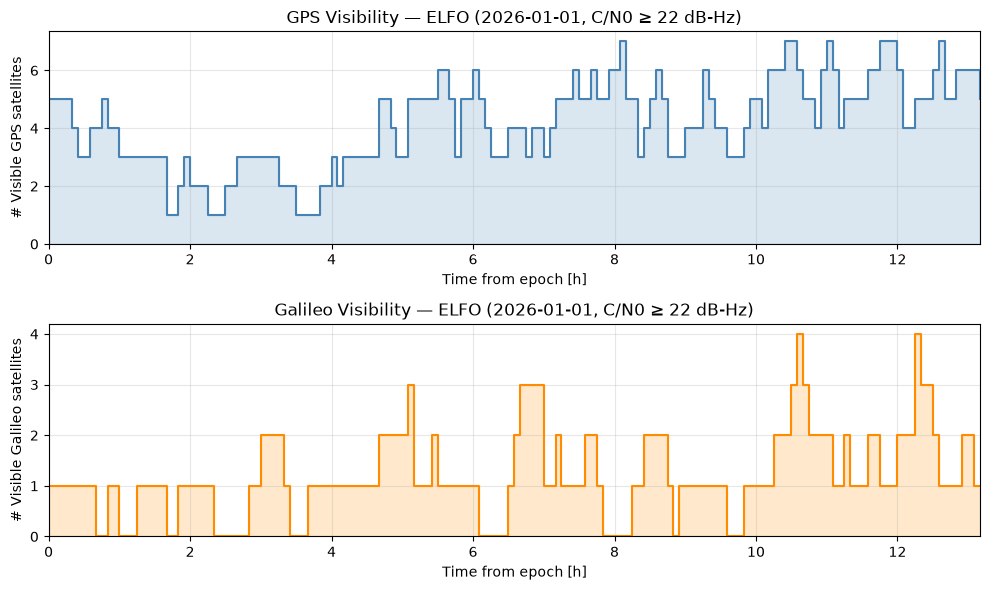

Peak: 10 sats,  Min: 1 sats


In [15]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# gps
ax[0].step(t_hrs, n_gps_vis, where='post', color='steelblue', linewidth=1.5)
ax[0].fill_between(t_hrs, n_gps_vis, step='post', alpha=0.2, color='steelblue')
ax[0].set_xlabel("Time from epoch [h]")
ax[0].set_ylabel("# Visible GPS satellites")
ax[0].set_title("GPS Visibility — ELFO (2026-01-01, C/N0 \u2265 22 dB-Hz)")
ax[0].set_xlim(0, t_hrs[-1])
ax[0].set_ylim(bottom=0)
ax[0].grid(True, alpha=0.3)

ax[1].step(t_hrs, n_gal_vis, where='post', color='darkorange', linewidth=1.5)
ax[1].fill_between(t_hrs, n_gal_vis, step='post', alpha=0.2, color='darkorange')
ax[1].set_xlabel("Time from epoch [h]")
ax[1].set_ylabel("# Visible Galileo satellites")
ax[1].set_title("Galileo Visibility — ELFO (2026-01-01, C/N0 \u2265 22 dB-Hz)")
ax[1].set_xlim(0, t_hrs[-1])
ax[1].set_ylim(bottom=0)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Peak: {n_vis.max()} sats,  Min: {n_vis.min()} sats")

## 11. Plot 2 — C/N0 Heat Map (Time x PRN)

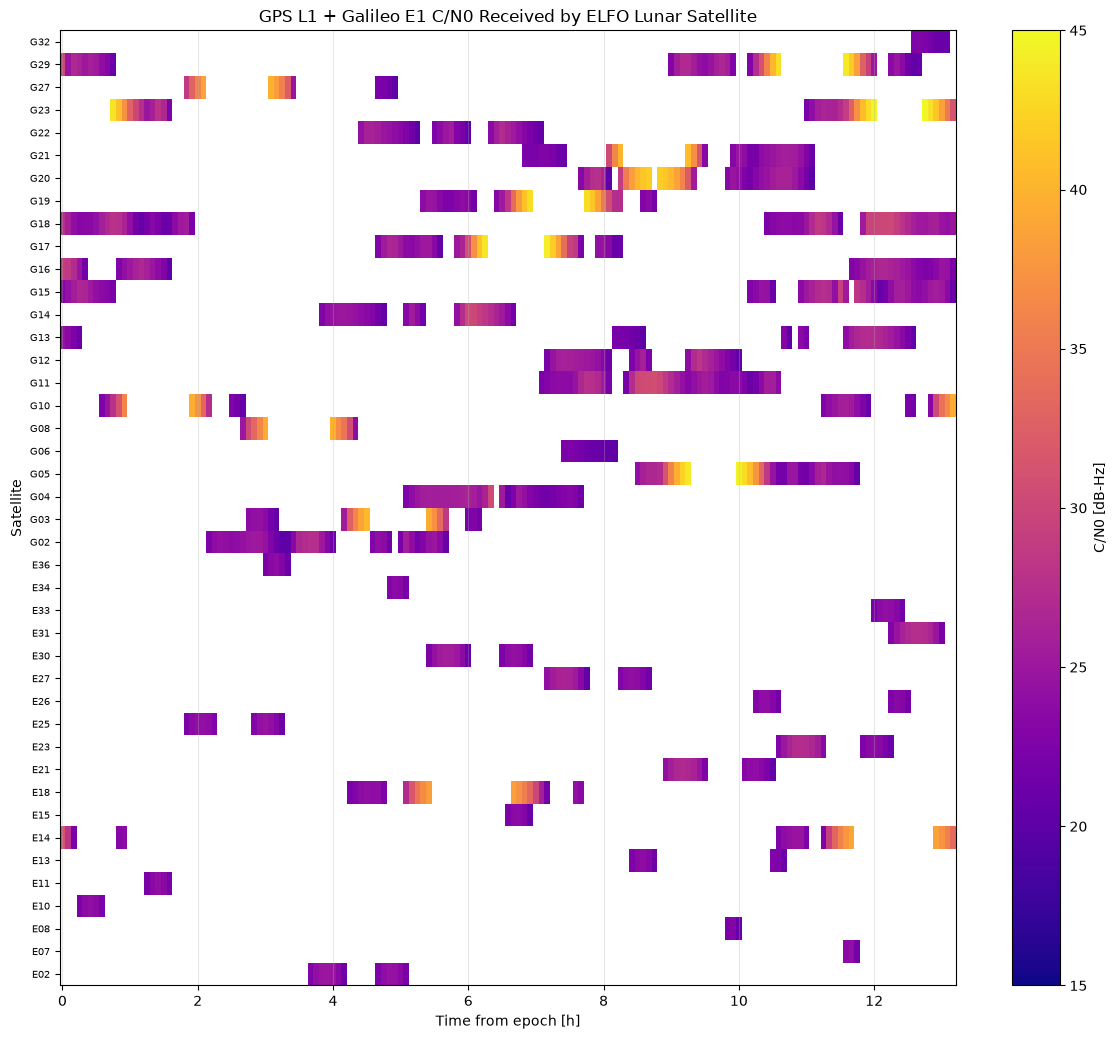

In [16]:
if len(links) > 0:
    all_sats = sorted(set(str(l[1]) for l in links),
                      key=lambda s: (s[0], int(s[1:])))
    sat_to_row = {s: r for r, s in enumerate(all_sats)}

    cn0_grid = np.full((len(all_sats), N_RX), np.nan)
    for t_hr, sat_id, cn0 in links:
        col = int(np.argmin(np.abs(t_hrs - float(t_hr))))
        cn0_grid[sat_to_row[str(sat_id)], col] = float(cn0)

    fig, ax = plt.subplots(figsize=(12, max(4, len(all_sats) * 0.25)))
    im = ax.pcolormesh(t_hrs, range(len(all_sats)), cn0_grid,
                       cmap='plasma', vmin=15, vmax=45, shading='nearest')
    plt.colorbar(im, ax=ax, label='C/N0 [dB-Hz]')
    ax.set_xlabel('Time from epoch [h]')
    ax.set_ylabel('Satellite')
    ax.set_title('GPS L1 + Galileo E1 C/N0 Received by ELFO Lunar Satellite')
    ax.set_yticks(range(len(all_sats)))
    ax.set_yticklabels(all_sats, fontsize=7)
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No visible links.')


## 12. Plot 3 — Lunar Satellite Directions on GPS TX Antenna Patterns

For each visible link we project the lunar satellite's direction into the GPS/Galileo satellite's attitude frame (nadir-pointing boresight = center) and scatter-plot on the L1/E1 transmit-antenna gain colormesh.  

In [17]:
# Project every visible link into the corresponding TX attitude frame.
# link_angles entries: (const, prn, phi_deg=off-boresight, theta_deg=azimuth, cn0, t_hr)
link_angles = []

for i, ep in enumerate(epoch_results):
    t_tai_i = float(ep.receive_time)
    t_tdb_i = float(pnt.convert_time(t_tai_i, pnt.TAI, pnt.TDB))
    rx_pos  = rv_eci[i, :3]
    sun_pos = np.array(pnt.get_body_pos(t_tdb_i, pnt.EARTH, pnt.SUN, pnt.ECI))

    for ch in ep.channels:
        prn   = ch.prn
        # Use gnss_const — PRN numbers overlap between GPS (1–32) and Galileo (1–36)
        const = 'G' if ch.gnss_const == pnt.GnssConst.GPS else 'E'
        tx_pos = np.array(ch.tx_state[:3])
        att    = pnt.GnssAttitude(tx_pos, sun_pos)
        u      = rx_pos - tx_pos
        u     /= np.linalg.norm(u)
        theta_r, phi_r = att.get_angles(np.array(u))  # theta=azimuth, phi=off-boresight
        link_angles.append((
            const,
            prn,
            float(np.degrees(phi_r)),    # off-boresight [deg]
            float(np.degrees(theta_r)),  # azimuth [deg]
            float(ch.cn0_dbhz),
            t_hrs[i]
        ))

print(f'Computed direction angles for {len(link_angles)} links')


Computed direction angles for 844 links


GPS: displaying PRNs [2, 11, 15, 18, 20, 29]


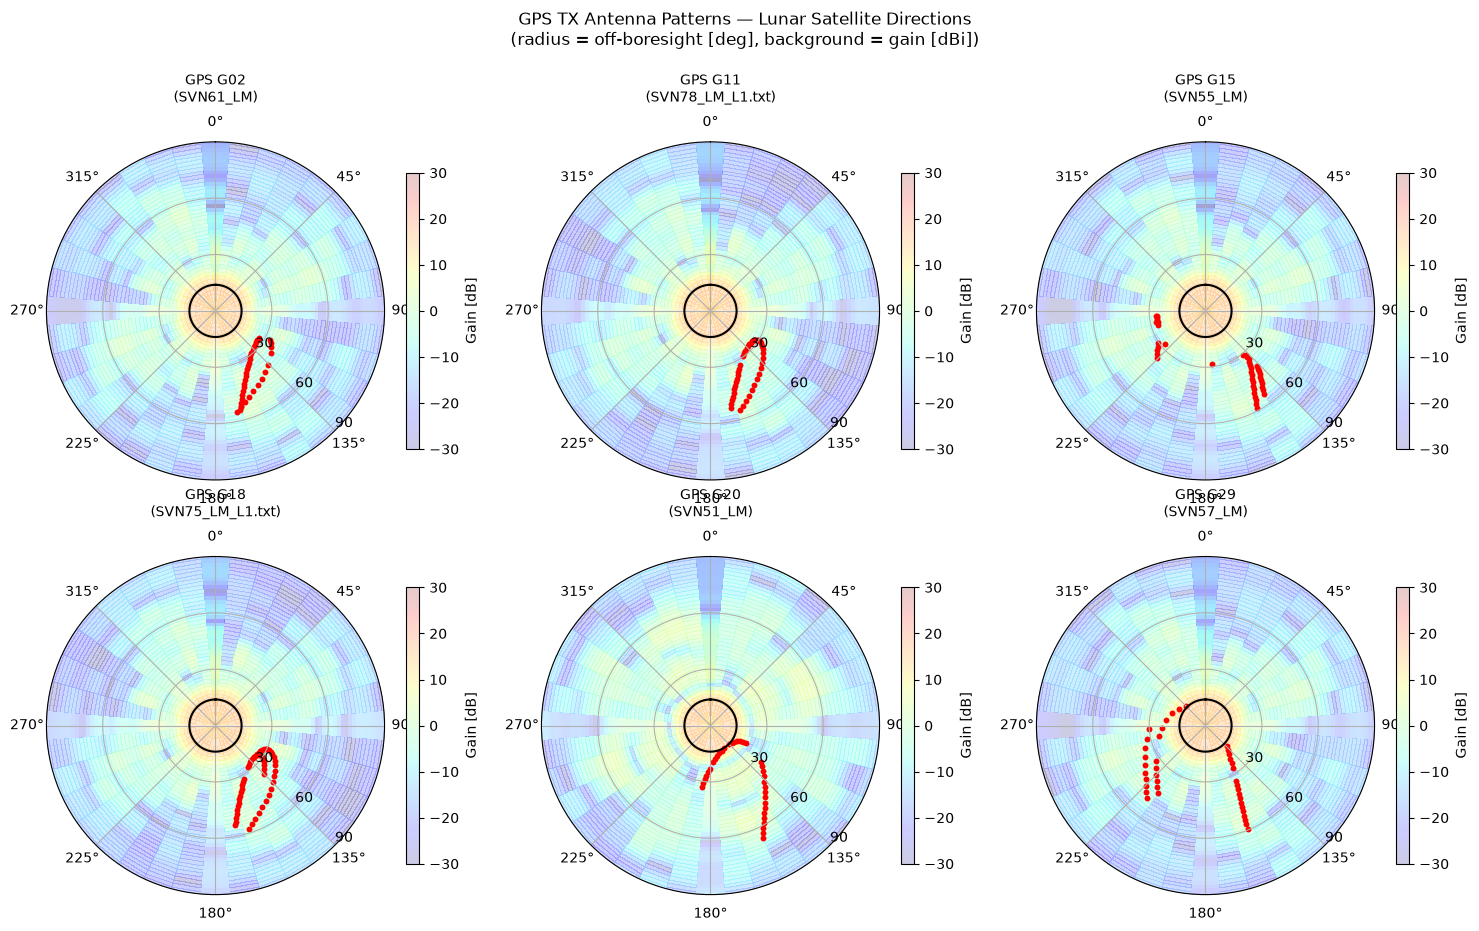

Galileo: displaying PRNs [14, 18, 21, 23, 27, 30]


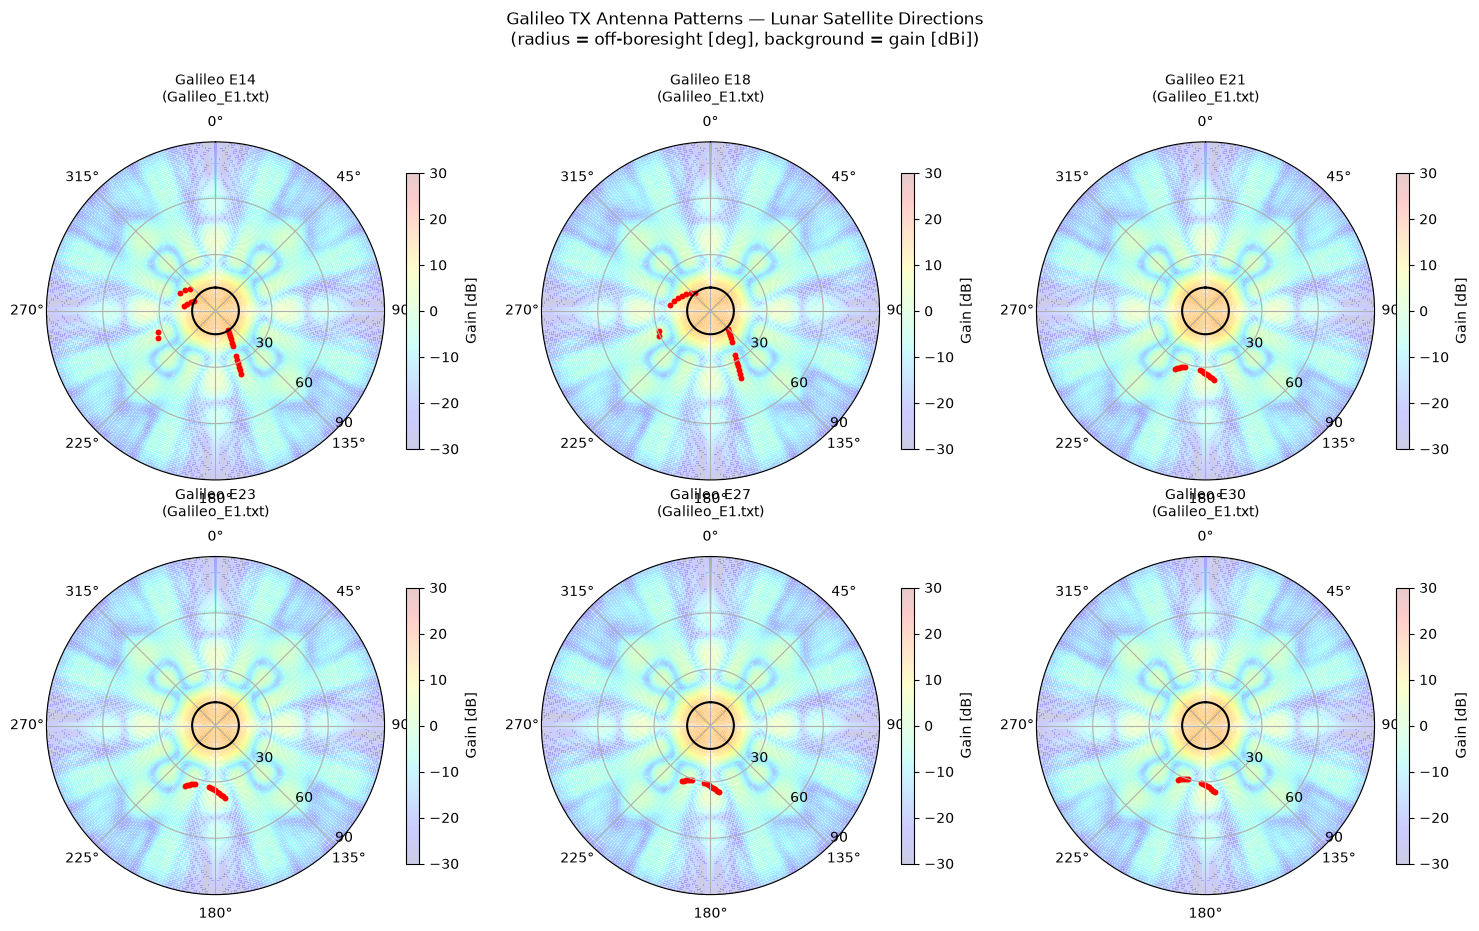

In [18]:
def plot_antenna_polar(ax, antenna, cmap='jet', title=None):
    phi   = np.array(antenna.get_phi_vector())
    theta = np.array(antenna.get_theta_vector())
    gain  = np.array(antenna.get_gain_matrix())
    mask  = phi >= 0
    phi   = phi[mask]
    gain  = gain[mask, :]
    T, P  = np.meshgrid(np.radians(theta), phi)
    mesh  = ax.pcolormesh(T, P, gain, cmap=cmap, shading='auto',
                          vmin=-30, vmax=30, alpha=0.2)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rlim(0, 90)
    ax.set_rticks([30, 60, 90])
    ax.set_rlabel_position(135)
    if title:
        ax.set_title(title, pad=10, fontsize=9)
    return mesh

gps_sma = 26560e3
gal_sma = 29600e3
earth_half_ang_deg_gps = np.degrees(np.arcsin(pnt.R_EARTH / gps_sma))
earth_half_ang_deg_gal = np.degrees(np.arcsin(pnt.R_EARTH / gal_sma))
_theta_circle = np.linspace(0, 2 * np.pi, 360)

if len(link_angles) == 0:
    print('No links to display.')
else:
    gps_links = [(a[1], a[2], a[3], a[4]) for a in link_angles if a[0] == 'G']
    gal_links = [(a[1], a[2], a[3], a[4]) for a in link_angles if a[0] == 'E']

    for const_label, const_links, constellation, freq, has_tx in [
        ('GPS',     gps_links, gps_const, pnt.GnssFreq.L1, has_tx_info),
        ('Galileo', gal_links, gal_const, pnt.GnssFreq.E1, has_gal_tx_info),
    ]:
        if not const_links:
            print(f'No {const_label} links.')
            continue

        prn_counts   = Counter(a[0] for a in const_links)
        display_prns = sorted(prn for prn, _ in prn_counts.most_common(6))
        print(f'{const_label}: displaying PRNs {display_prns}')

        ncols = 3
        nrows = int(np.ceil(len(display_prns) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                                  subplot_kw={'projection': 'polar'})
        axes = np.array(axes).ravel()

        for idx, prn in enumerate(display_prns):
            ax = axes[idx]
            ant_name = ''
            if has_tx and constellation.has_transmitter_info(prn, freq):
                ant = constellation.get_transmitter_antenna(prn, freq)
                ant_name = ant.name
                mesh = plot_antenna_polar(ax, ant, cmap='jet')
                cbar = fig.colorbar(mesh, ax=ax, shrink=0.8)
                cbar.set_label('Gain [dB]', fontsize=10)

            earth_half_ang_deg = earth_half_ang_deg_gps if const_label == 'GPS' else earth_half_ang_deg_gal
            ax.plot(_theta_circle, np.full(360, earth_half_ang_deg),
                    'k-', linewidth=1.5, zorder=4)

            prn_data = [(a[1], a[2], a[3]) for a in const_links if a[0] == prn]
            if prn_data:
                phi_d, th_d, cn0_d = zip(*prn_data)
                ax.scatter(np.radians(th_d), phi_d, color='red', s=18, linewidths=0)

            ax.set_theta_zero_location('N')
            ax.set_theta_direction(-1)
            ax.set_rlim(0, 90)
            ax.set_rticks([30, 60, 90])
            ax.set_rlabel_position(135)
            prefix = 'G' if const_label == 'GPS' else 'E'
            title_str = f'{const_label} {prefix}{prn:02d}'
            if ant_name:
                title_str += f'\n({ant_name})'
            ax.set_title(title_str, pad=10, fontsize=10)

        for idx in range(len(display_prns), len(axes)):
            axes[idx].set_visible(False)

        fig.suptitle(
            f'{const_label} TX Antenna Patterns — Lunar Satellite Directions\n'
            '(radius = off-boresight [deg], background = gain [dBi])',
            fontsize=12, y=1.01
        )
        plt.tight_layout()
        plt.show()
